In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

path = "lab1_data/var13.txt"

df = pd.read_csv(path, sep=None, engine="python", header=None, decimal=",", comment="#")

x = df.apply(pd.to_numeric, errors="coerce").to_numpy().ravel()
x = x[np.isfinite(x)]

print(f"Объём выборки n = {len(x)}")
print("Первые 10 значений:", x[:10])


Объём выборки n = 722
Первые 10 значений: [1.000000e-01 5.020000e+02 3.200000e+00 5.399000e+03 1.000000e-01
 2.895000e+03 3.505000e+00 8.000000e+00 1.018328e+00 4.339070e-01]


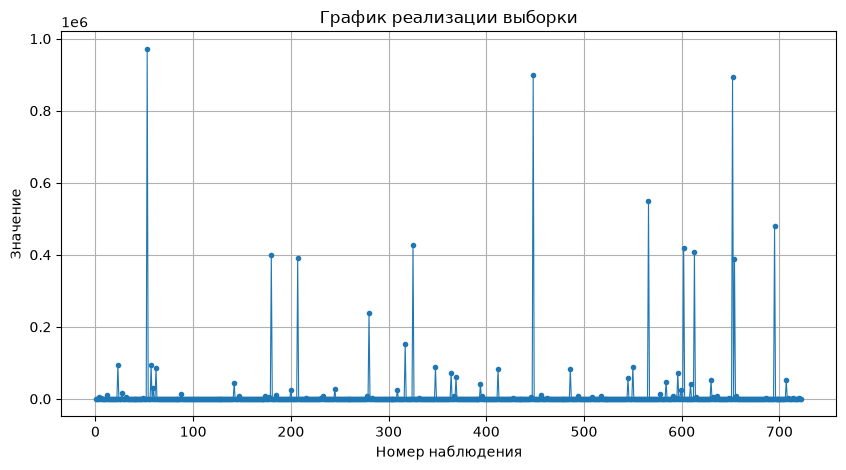

In [3]:
plt.figure()
plt.plot(np.arange(1, len(x) + 1), x, marker=".", linestyle="-", linewidth=0.8)
plt.xlabel("Номер наблюдения")
plt.ylabel("Значение")
plt.title("График реализации выборки")
plt.show()

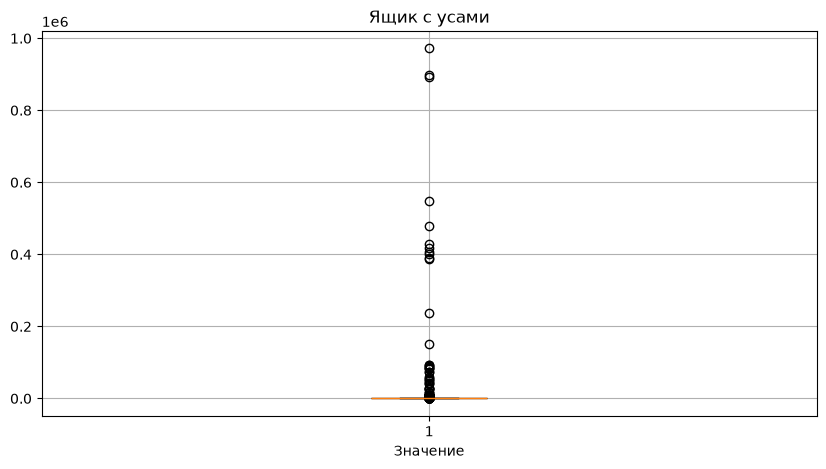

In [10]:
plt.figure()
plt.title("Ящик с усами")
plt.xlabel("Значение")
plt.boxplot(x, orientation="vertical", patch_artist=True)  # matplotlib >= 3.9
plt.show()

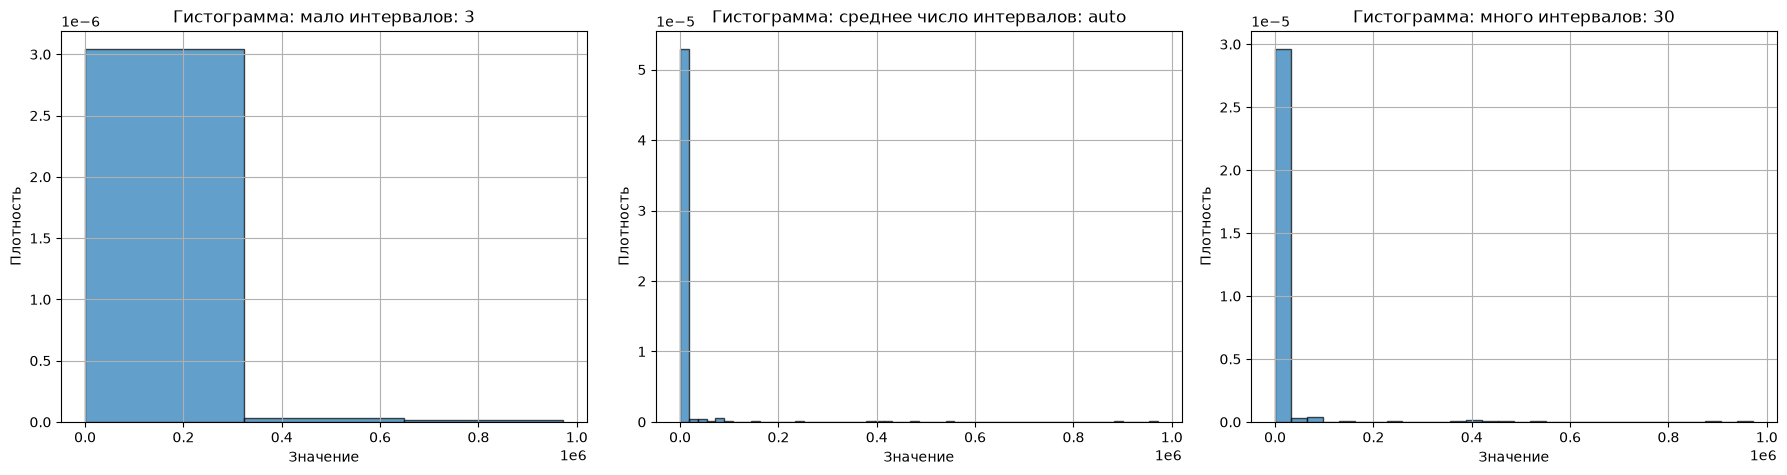

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins_variants = [
    (3, "мало интервалов: 3"),
    ("auto", "среднее число интервалов: auto"),
    (30, "много интервалов: 30"),
]

for ax, (bins, title) in zip(axes, bins_variants):
    ax.hist(x, bins=bins, density=True, edgecolor="black", alpha=0.7)
    ax.set_title(f"Гистограмма: {title}")
    ax.set_xlabel("Значение")
    ax.set_ylabel("Плотность")

plt.tight_layout()
plt.show()

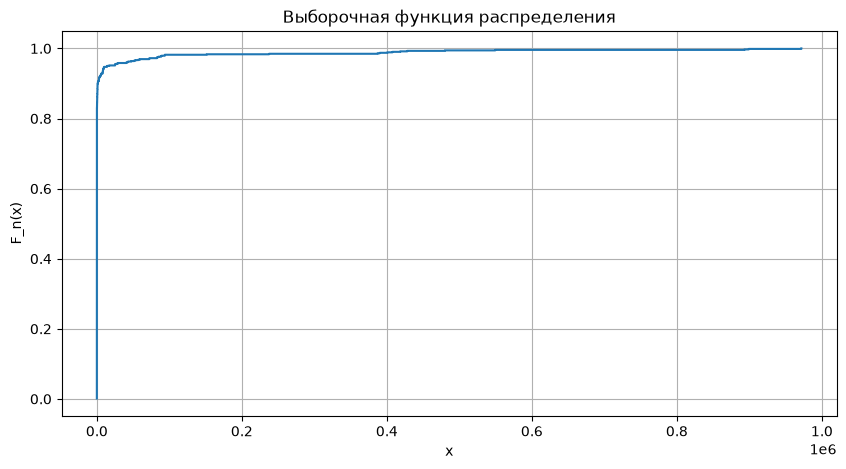

In [6]:
xs = np.sort(x)
ys = np.arange(1, len(x) + 1) / len(x)

plt.figure()
plt.step(xs, ys, where="post")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Выборочная функция распределения")
plt.show()

In [7]:
n = len(x)
mean = np.mean(x)
std = np.std(x, ddof=1)          # выборочное СКО
var = np.var(x, ddof=1)          # выборочная дисперсия
median = np.median(x)
q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1
skewness = stats.skew(x, bias=False)          # коэффициент асимметрии
kurtosis = stats.kurtosis(x, fisher=True, bias=False)  # эксцесс, excess
xmin, xmax = np.min(x), np.max(x)

print(f"n                 = {n}")
print(f"Среднее           = {mean:.6g}")
print(f"Дисперсия         = {var:.6g}")
print(f"СКО               = {std:.6g}")
print(f"Медиана           = {median:.6g}")
print(f"Q1                = {q1:.6g}")
print(f"Q3                = {q3:.6g}")
print(f"IQR = Q3 - Q1     = {iqr:.6g}")
print(f"Асимметрия        = {skewness:.6g}")
print(f"Эксцесс           = {kurtosis:.6g}")
print(f"Минимум           = {xmin:.6g}")
print(f"Максимум          = {xmax:.6g}")
print(f"Размах            = {xmax - xmin:.6g}")

n                 = 722
Среднее           = 11318.9
Дисперсия         = 5.75241e+09
СКО               = 75844.6
Медиана           = 1.38294
Q1                = 0.451813
Q3                = 8
IQR = Q3 - Q1     = 7.54819
Асимметрия        = 9.29747
Эксцесс           = 96.6557
Минимум           = 0
Максимум          = 971734
Размах            = 971734
